# Time scaling of circuit simulation

In [4]:
import time

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from torx import DiscretePCircuit, PCNOT, PNOT, PSWAP, SampleSimulator

## Scaling w.r.t. circuit depth

In [5]:
num_pbits = 100
rng = np.random.default_rng(seed=7)

gates = []
gates = gates + [PNOT(jnp.array(rng.uniform()), i) for i in range(num_pbits)]
gates = gates + [
    PCNOT(jnp.array(rng.uniform()), [i, (i + 1) % num_pbits]) for i in range(num_pbits)
]

sim = SampleSimulator(num_samples=10000)
key = jax.random.key(100)
init_state = jnp.zeros(num_pbits)

num_layers_dev = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]
compile_times_dev = []
execute_times_dev = []

for layers in num_layers_dev:
    print("Num layers:", layers)

    circuit = sim.build_circuit(DiscretePCircuit(gates * layers))

    expval_jit = eqx.filter_jit(sim.expval_all)

    start = time.time()
    expval_jit(circuit, init_state, key).block_until_ready()
    compile_time = time.time() - start

    compile_times_dev.append(compile_time)
    print("Compile time:", compile_time)

    start = time.time()
    res = expval_jit(circuit, init_state, key).block_until_ready()
    execute_time = time.time() - start

    execute_times_dev.append(execute_time)

    print("Execute time:", execute_time)

Num layers: 1
Compile time: 0.18858718872070312
Execute time: 0.025553464889526367
Num layers: 2
Compile time: 0.19942617416381836
Execute time: 0.04986429214477539
Num layers: 4
Compile time: 0.24780535697937012
Execute time: 0.09629178047180176
Num layers: 8
Compile time: 0.3479914665222168
Execute time: 0.198652982711792
Num layers: 16
Compile time: 0.5588421821594238
Execute time: 0.3870108127593994
Num layers: 32
Compile time: 0.9605987071990967
Execute time: 0.7866103649139404
Num layers: 64
Compile time: 1.7464604377746582
Execute time: 1.5462706089019775
Num layers: 128
Compile time: 3.305614948272705
Execute time: 3.0798258781433105
Num layers: 256
Compile time: 6.393682479858398
Execute time: 6.126001596450806
Num layers: 512
Compile time: 12.681353330612183
Execute time: 12.270147562026978


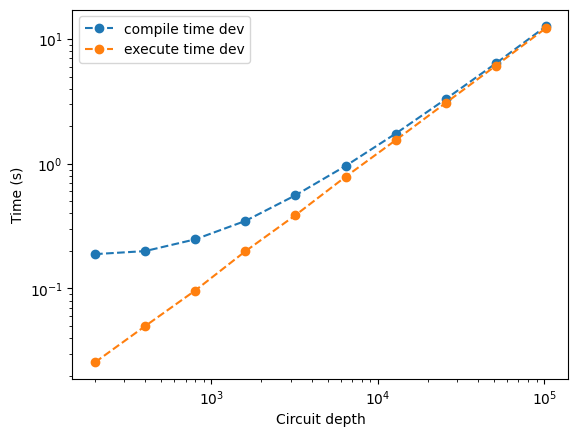

In [6]:
plt.plot(
    np.array(num_layers_dev) * len(gates),
    np.array(compile_times_dev),
    "o--",
    label="compile time dev",
)
plt.plot(
    np.array(num_layers_dev) * len(gates),
    np.array(execute_times_dev),
    "o--",
    label="execute time dev",
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Circuit depth")
plt.ylabel("Time (s)")
plt.legend(loc="best")
plt.show()

## Scaling w.r.t number of pbits

In [7]:
rng = np.random.default_rng(seed=7)

sim = SampleSimulator(num_samples=10000)
key = jax.random.key(100)

num_pbits_dev = [2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000]
compile_times_dev = []
execute_times_dev = []

for pbits in num_pbits_dev:
    print("Num pbits:", pbits)

    gates = [PSWAP(jnp.array(rng.uniform()), [pbits - 2, pbits - 1])] * 5000
    circuit = sim.build_circuit(DiscretePCircuit(gates))
    init_state = jnp.zeros(pbits)

    expval_jit = eqx.filter_jit(sim.expval_all)

    start = time.time()
    expval_jit(circuit, init_state, key).block_until_ready()
    compile_time = time.time() - start

    compile_times_dev.append(compile_time)
    print("Compile time:", compile_time)

    start = time.time()
    res = expval_jit(circuit, init_state, key).block_until_ready()
    execute_time = time.time() - start

    execute_times_dev.append(execute_time)

    print("Execute time:", execute_time)

Num pbits: 2
Compile time: 0.40447187423706055
Execute time: 0.22806262969970703
Num pbits: 5
Compile time: 0.4004673957824707
Execute time: 0.23050761222839355
Num pbits: 10
Compile time: 0.437603235244751
Execute time: 0.2689235210418701
Num pbits: 20
Compile time: 0.7141518592834473
Execute time: 0.5564224720001221
Num pbits: 50
Compile time: 0.8007512092590332
Execute time: 0.6297848224639893
Num pbits: 100
Compile time: 0.8537218570709229
Execute time: 0.6588730812072754
Num pbits: 200
Compile time: 0.7862207889556885
Execute time: 0.6161956787109375
Num pbits: 500
Compile time: 0.8527007102966309
Execute time: 0.6721765995025635
Num pbits: 1000
Compile time: 0.9241931438446045
Execute time: 0.7413301467895508
Num pbits: 2000
Compile time: 0.8647587299346924
Execute time: 0.6270942687988281
Num pbits: 5000
Compile time: 0.8285467624664307
Execute time: 0.6815328598022461
Num pbits: 10000
Compile time: 0.8618161678314209
Execute time: 0.7410588264465332
Num pbits: 20000
Compile tim

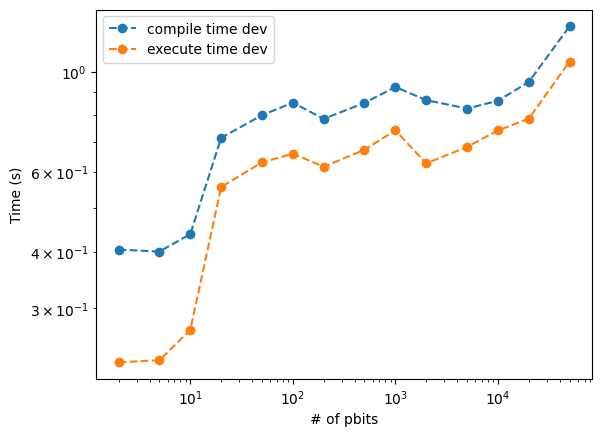

In [8]:
plt.plot(
    np.array(num_pbits_dev),
    np.array(compile_times_dev),
    "o--",
    label="compile time dev",
)
plt.plot(
    np.array(num_pbits_dev),
    np.array(execute_times_dev),
    "o--",
    label="execute time dev",
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("# of pbits")
plt.ylabel("Time (s)")
plt.legend(loc="best")
plt.show()

## Scaling w.r.t. number of samples

In [9]:
num_pbits = 100
rng = np.random.default_rng(seed=7)

gates = []
gates = gates + [PNOT(jnp.array(rng.uniform()), i) for i in range(num_pbits)]
gates = gates + [
    PCNOT(jnp.array(rng.uniform()), [i, (i + 1) % num_pbits]) for i in range(num_pbits)
]

circuit = SampleSimulator.build_circuit(DiscretePCircuit(gates * 25))
init_state = jnp.zeros(num_pbits)
key = jax.random.key(100)

num_samples_dev = [100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000, 200000]
compile_times_dev = []
execute_times_dev = []

for num_samples in num_samples_dev:
    print("Num samples:", num_samples)

    sim = SampleSimulator(num_samples=num_samples)
    expval_jit = eqx.filter_jit(sim.expval_all)

    start = time.time()
    expval_jit(circuit, init_state, key).block_until_ready()
    compile_time = time.time() - start

    compile_times_dev.append(compile_time)
    print("Compile time:", compile_time)

    start = time.time()
    res = expval_jit(circuit, init_state, key).block_until_ready()
    execute_time = time.time() - start

    execute_times_dev.append(execute_time)

    print("Execute time:", execute_time)

Num samples: 100
Compile time: 0.20594000816345215
Execute time: 0.004194974899291992
Num samples: 200
Compile time: 0.19233965873718262
Execute time: 0.006702423095703125
Num samples: 500
Compile time: 0.20576214790344238
Execute time: 0.017071247100830078
Num samples: 1000
Compile time: 0.21343421936035156
Execute time: 0.031108856201171875
Num samples: 2000
Compile time: 0.2854421138763428
Execute time: 0.09861969947814941
Num samples: 5000
Compile time: 0.5088791847229004
Execute time: 0.3227362632751465
Num samples: 10000
Compile time: 0.6093497276306152
Execute time: 0.6081526279449463
Num samples: 20000
Compile time: 1.2015972137451172
Execute time: 1.031008243560791
Num samples: 50000
Compile time: 2.018331289291382
Execute time: 1.870408296585083
Num samples: 100000
Compile time: 2.8452367782592773
Execute time: 2.5978188514709473
Num samples: 200000
Compile time: 4.397772789001465
Execute time: 4.275981903076172


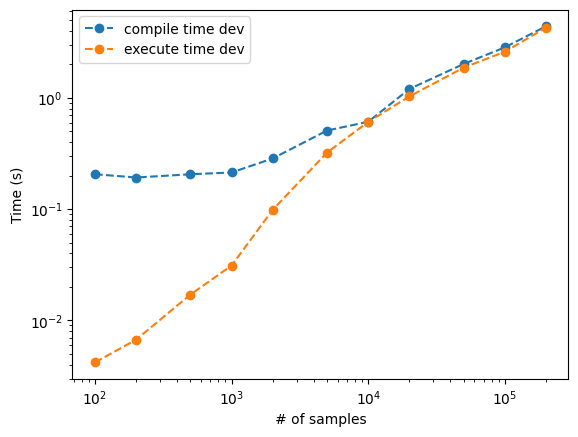

In [10]:
plt.plot(
    np.array(num_samples_dev),
    np.array(compile_times_dev),
    "o--",
    label="compile time dev",
)
plt.plot(
    np.array(num_samples_dev),
    np.array(execute_times_dev),
    "o--",
    label="execute time dev",
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("# of samples")
plt.ylabel("Time (s)")
plt.legend(loc="best")
plt.show()